In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [40]:

file_path = r"C:\Users\karthik\Downloads\voruganti-karthik\datasets.csv"

df = pd.read_csv(file_path)


df.head()

,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [41]:

df["Declaration Date"] = pd.to_datetime(df["Declaration Date"], errors="coerce")

df["year"] = df["Declaration Date"].dt.year
df["month"] = df["Declaration Date"].dt.month

df = df.rename(columns={
    "Disaster Type": "incidentType",
    "State": "state",
    "Individuals & Households Program": "ihProgramDeclared",
    "Public Assistance Program": "paProgramDeclared"
})


df["ihProgramDeclared"] = df["ihProgramDeclared"].map({"Yes":1, "No":0})
df["paProgramDeclared"] = df["paProgramDeclared"].map({"Yes":1, "No":0})

df.head()

,Declaration Number,Declaration Type,Declaration Date,state,County,incidentType,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,ihProgramDeclared,paProgramDeclared,Hazard Mitigation Program,year,month
0,DR-1,Disaster,1953-05-02,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,0,1,Yes,1953,5
1,DR-2,Disaster,1953-05-15,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,0,1,Yes,1953,5
2,DR-3,Disaster,1953-05-29,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,0,1,Yes,1953,5
3,DR-4,Disaster,1953-06-02,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,0,1,Yes,1953,6
4,DR-5,Disaster,1953-06-06,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,0,1,Yes,1953,6


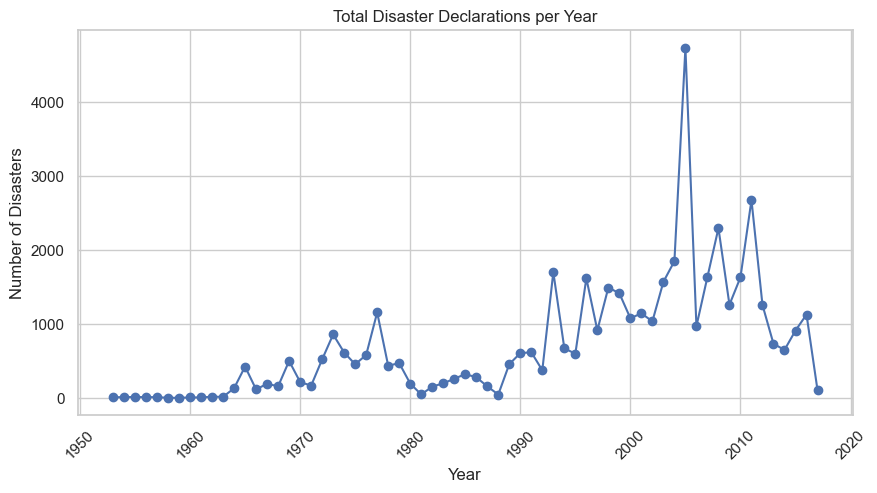

In [42]:
yearly_counts = df.groupby("year").size()

plt.figure(figsize=(10,5))
plt.plot(yearly_counts.index, yearly_counts.values, marker="o")

plt.title("Total Disaster Declarations per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.xticks(rotation=45)

plt.show()

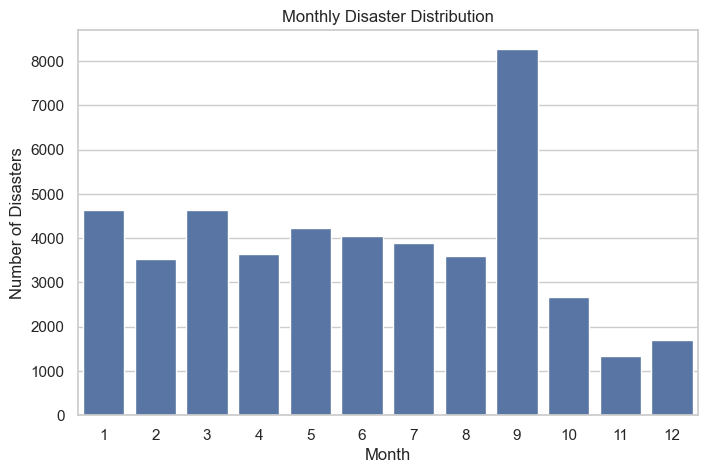

In [43]:
monthly_counts = df.groupby("month").size()

plt.figure(figsize=(8,5))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)

plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()

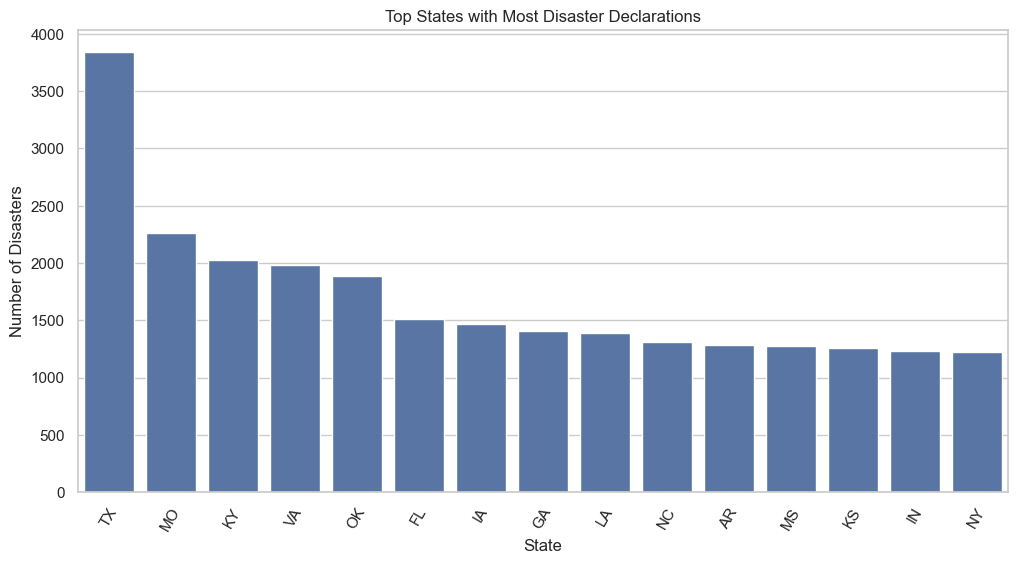

In [44]:
state_counts = df.groupby("state").size().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=state_counts.index, y=state_counts.values)

plt.title("Top States with Most Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.xticks(rotation=60)

plt.show()

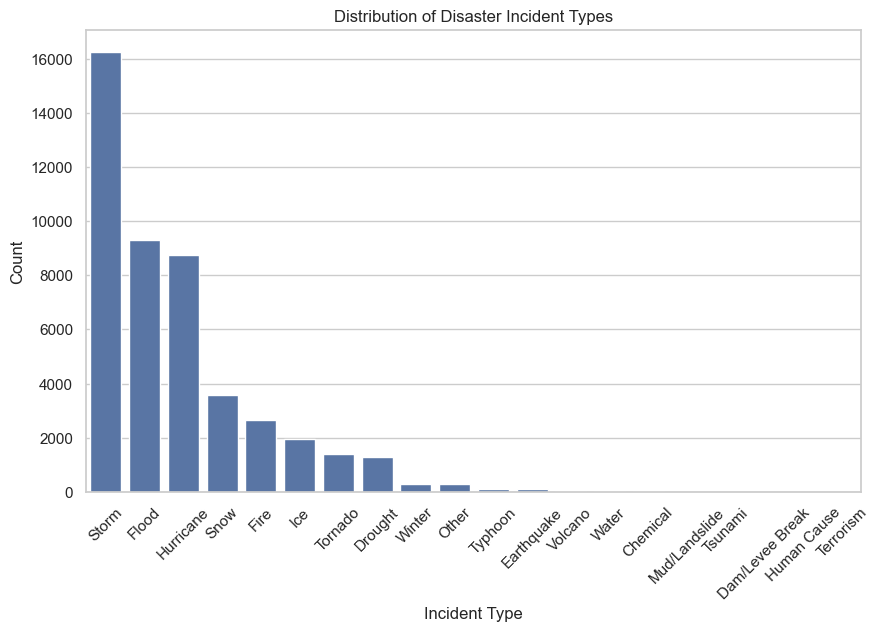

In [45]:
incident_counts = df["incidentType"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=incident_counts.index, y=incident_counts.values)

plt.title("Distribution of Disaster Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

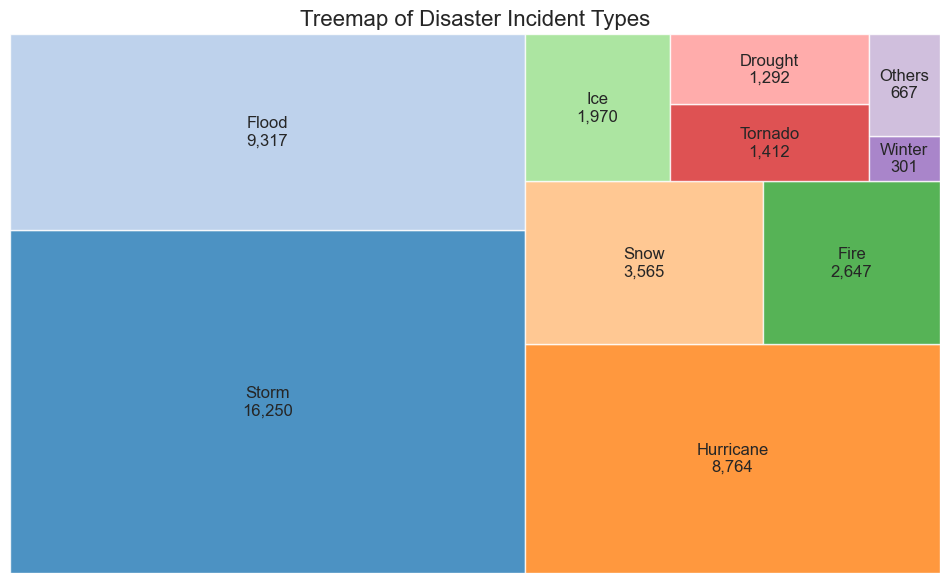

In [46]:
import squarify

# Count disaster types
incident_counts = df["incidentType"].value_counts()

# Floor small categories into Others for cleaner visual
small_threshold = 300
small_items = incident_counts[incident_counts < small_threshold]
incident_clean = incident_counts[incident_counts >= small_threshold].copy()

if small_items.sum() > 0:
    incident_clean["Others"] = small_items.sum()

plt.figure(figsize=(12,7))

# Create treemap
squarify.plot(
    sizes=incident_clean.values,
    label=[f"{name}\n{value:,}" for name, value in zip(incident_clean.index, incident_clean.values)],
    alpha=0.8,
    color=plt.cm.tab20.colors
)

plt.title("Treemap of Disaster Incident Types", fontsize=16)

plt.axis("off")

plt.show()

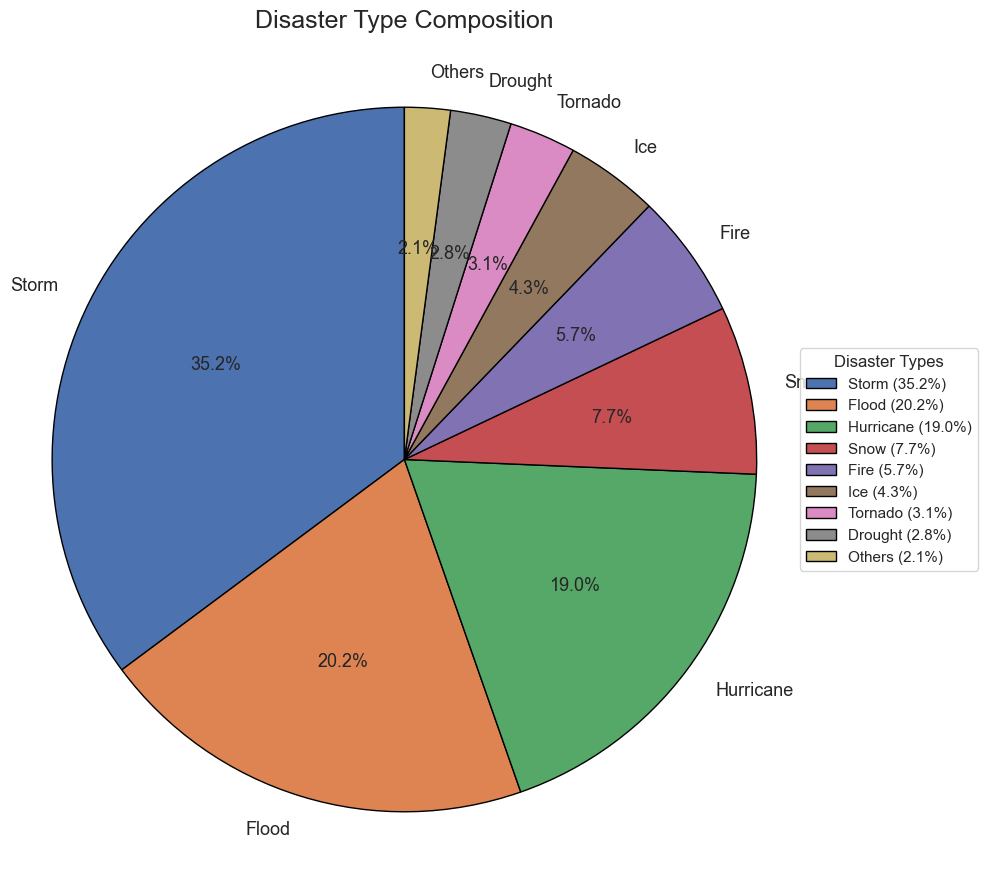

In [47]:
incident_counts = df["incidentType"].value_counts()

percentages = (incident_counts / incident_counts.sum()) * 100

small = percentages[percentages < 2.5].index
incident_clean = incident_counts.drop(small)

if len(small) > 0:
    incident_clean["Others"] = incident_counts[small].sum()


percent_clean = (incident_clean / incident_clean.sum()) * 100


legend_labels = [
    f"{name} ({percent_clean[name]:.1f}%)"
    for name in incident_clean.index
]

plt.figure(figsize=(10,11))

plt.pie(
    incident_clean,
    labels=incident_clean.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':13},
    wedgeprops={'edgecolor':'black'}
)

plt.title("Disaster Type Composition", fontsize=18)


plt.legend(
    legend_labels,
    title="Disaster Types",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.axis('equal')

plt.show()

In [48]:
state_incident = df.groupby(["state","incidentType"]).size().unstack(fill_value=0)

state_incident.head()

incidentType,Chemical,Dam/Levee Break,Drought,Earthquake,Fire,Flood,Human Cause,Hurricane,Ice,Mud/Landslide,Other,Snow,Storm,Terrorism,Tornado,Tsunami,Typhoon,Volcano,Water,Winter
state,,,,,,,,,,,,,,,,,,,,
AK,0,0,0,7,16,46,0,0,0,0,4,4,64,0,0,0,0,0,0,14
AL,0,0,67,0,11,104,0,368,0,0,0,67,529,0,61,0,0,0,0,0
AR,0,0,32,0,0,235,0,93,207,0,0,17,603,0,95,0,0,0,0,0
AS,0,0,5,5,0,5,0,15,0,0,0,0,7,0,0,0,18,0,0,0
AZ,0,0,8,0,44,77,0,15,0,0,0,0,65,0,0,0,0,0,0,1


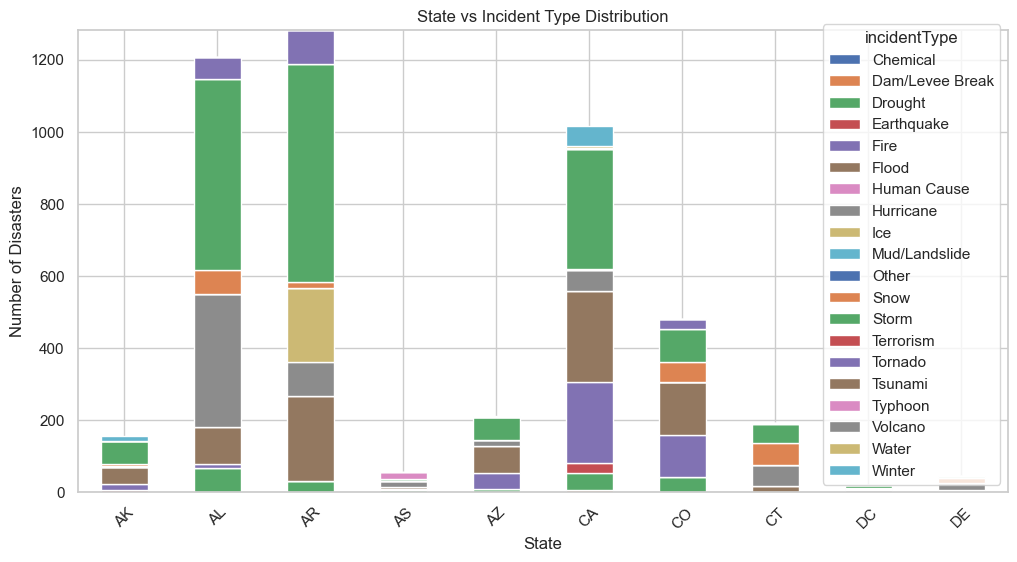

In [49]:
state_incident.head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("State vs Incident Type Distribution")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.xticks(rotation=45)

plt.show()

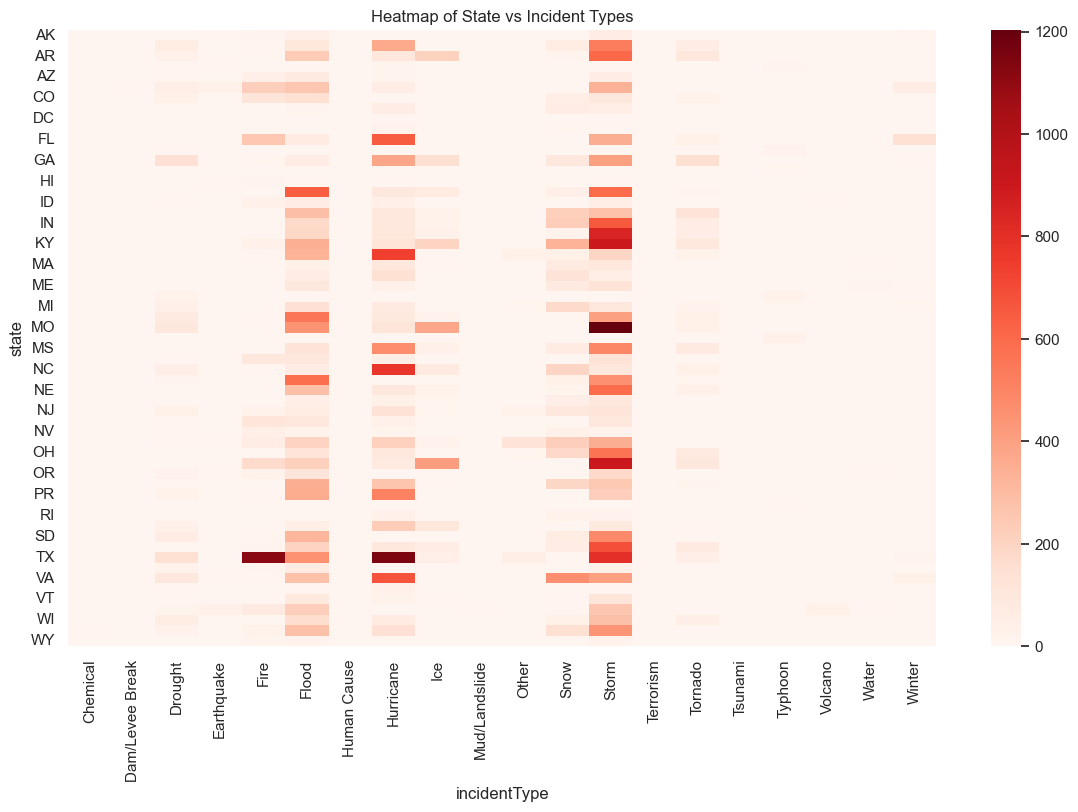

In [50]:
plt.figure(figsize=(14,8))

sns.heatmap(state_incident, cmap="Reds")

plt.title("Heatmap of State vs Incident Types")

plt.show()

In [51]:
assistance_analysis = df.groupby("incidentType")[["ihProgramDeclared","paProgramDeclared"]].sum()

assistance_analysis

,ihProgramDeclared,paProgramDeclared
incidentType,,
Chemical,0,17
Dam/Levee Break,0,6
Drought,0,1287
Earthquake,29,98
Fire,431,2498
Flood,628,9143
Human Cause,0,6
Hurricane,2097,8720
Ice,16,1960


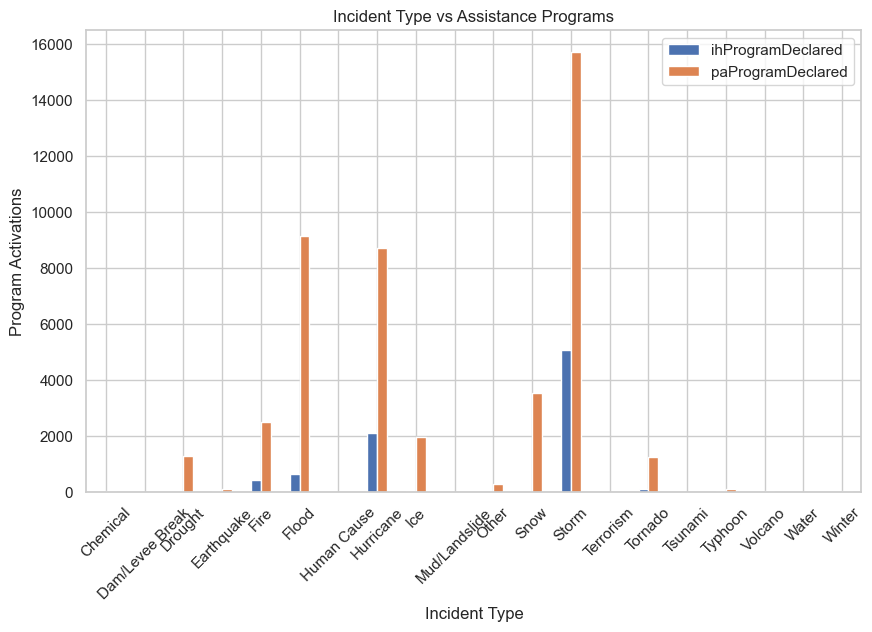

In [52]:
assistance_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Incident Type vs Assistance Programs")
plt.xlabel("Incident Type")
plt.ylabel("Program Activations")

plt.xticks(rotation=45)

plt.show()


This project analyzed the US Natural Disaster dataset to understand patterns and trends in disaster declarations.
 In Milestone-1, the dataset was cleaned and explored to ensure accurate analysis.
 In Milestone-2 focused on temporal analysis, which helped identify how disaster occurrences change over time and revealed yearly and monthly trends.
 Milestone-3 examined geographic patterns, highlighting the states that experience the highest number of disasters.
  Finally, Milestone-4 analyzed the distribution of disaster incident types and their relationship with disaster assistance programs.

By combining these analyses, the project provides a comprehensive understanding of when, where, and what types of disasters occur most frequently. 
These insights can support better disaster preparedness, planning, and resource allocation for emergency management authorities.
